## Churn Prediction

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

In [6]:
df = pd.read_excel(r"..\raw_datasets\Telco_customer_churn.xlsx")
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [7]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [8]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [10]:
df['CustomerID'].value_counts()

CustomerID
3668-QPYBK    1
9169-BSVIN    1
0206-OYVOC    1
6418-HNFED    1
8805-JNRAZ    1
             ..
6797-UCJHZ    1
5016-IBERQ    1
3003-CMDUU    1
5148-HKFIR    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

In [11]:
df=df.drop('CustomerID',axis=1)

In [12]:
# for every column in df check no of unique values are present and print the column name and unique values
for col in df.columns:
    print(col,df[col].nunique())

Count 1
Country 1
State 1
City 1129
Zip Code 1652
Lat Long 1652
Latitude 1652
Longitude 1651
Gender 2
Senior Citizen 2
Partner 2
Dependents 2
Tenure Months 73
Phone Service 2
Multiple Lines 3
Internet Service 3
Online Security 3
Online Backup 3
Device Protection 3
Tech Support 3
Streaming TV 3
Streaming Movies 3
Contract 3
Paperless Billing 2
Payment Method 4
Monthly Charges 1585
Total Charges 6531
Churn Label 2
Churn Value 2
Churn Score 85
CLTV 3438
Churn Reason 20


In [13]:
df['Count'].unique()

array([1], dtype=int64)

In [14]:
# deleting the columns for which the unique values are 1
for col in df.columns:
    if df[col].nunique()==1:
        df=df.drop(col,axis=1)


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Zip Code           7043 non-null   int64  
 2   Lat Long           7043 non-null   object 
 3   Latitude           7043 non-null   float64
 4   Longitude          7043 non-null   float64
 5   Gender             7043 non-null   object 
 6   Senior Citizen     7043 non-null   object 
 7   Partner            7043 non-null   object 
 8   Dependents         7043 non-null   object 
 9   Tenure Months      7043 non-null   int64  
 10  Phone Service      7043 non-null   object 
 11  Multiple Lines     7043 non-null   object 
 12  Internet Service   7043 non-null   object 
 13  Online Security    7043 non-null   object 
 14  Online Backup      7043 non-null   object 
 15  Device Protection  7043 non-null   object 
 16  Tech Support       7043 

In [16]:
print(df['City'].value_counts())

City
Los Angeles       305
San Diego         150
San Jose          112
Sacramento        108
San Francisco     104
                 ... 
Healdsburg          4
Jenner              4
Philo               4
Point Arena         4
Olympic Valley      4
Name: count, Length: 1129, dtype: int64


In [17]:
# count the citys where the value count is more than 100 and append them in list
city_list=[]
for city in df['City'].value_counts().index:
    if df['City'].value_counts()[city]>50:
        city_list.append(city)

In [18]:
city_list

['Los Angeles',
 'San Diego',
 'San Jose',
 'Sacramento',
 'San Francisco',
 'Fresno',
 'Long Beach',
 'Oakland']

In [19]:
df.isnull().sum()

City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [20]:
df=df.drop('Churn Reason',axis=1)

In [21]:
df['City'].value_counts()

City
Los Angeles       305
San Diego         150
San Jose          112
Sacramento        108
San Francisco     104
                 ... 
Healdsburg          4
Jenner              4
Philo               4
Point Arena         4
Olympic Valley      4
Name: count, Length: 1129, dtype: int64

In [22]:
# in City column only the city with the names in city_list keep then as it is and remaing keep them as others
df['City'] = df['City'].astype(str).str.strip().str.lower()

city_list = [city.strip().lower() for city in city_list]

df['City'] = np.where(df['City'].isin(city_list), df['City'], 'Others')

In [23]:
df['City'].value_counts()

City
Others           6088
los angeles       305
san diego         150
san jose          112
sacramento        108
san francisco     104
fresno             64
long beach         60
oakland            52
Name: count, dtype: int64

In [24]:
df['City']=df["City"].map({"Others":0,"los angeles":1,"san diego":2,"san jose":3,"sacramento":4,"san francisco":5,"fresno":6,"long beach":7,"oakland":8})
df['City'].value_counts()

City
0    6088
1     305
2     150
3     112
4     108
5     104
6      64
7      60
8      52
Name: count, dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   int64  
 1   Zip Code           7043 non-null   int64  
 2   Lat Long           7043 non-null   object 
 3   Latitude           7043 non-null   float64
 4   Longitude          7043 non-null   float64
 5   Gender             7043 non-null   object 
 6   Senior Citizen     7043 non-null   object 
 7   Partner            7043 non-null   object 
 8   Dependents         7043 non-null   object 
 9   Tenure Months      7043 non-null   int64  
 10  Phone Service      7043 non-null   object 
 11  Multiple Lines     7043 non-null   object 
 12  Internet Service   7043 non-null   object 
 13  Online Security    7043 non-null   object 
 14  Online Backup      7043 non-null   object 
 15  Device Protection  7043 non-null   object 
 16  Tech Support       7043 

In [26]:
df['Zip Code'].nunique()

1652

In [27]:
df=df.drop('Zip Code',axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   int64  
 1   Lat Long           7043 non-null   object 
 2   Latitude           7043 non-null   float64
 3   Longitude          7043 non-null   float64
 4   Gender             7043 non-null   object 
 5   Senior Citizen     7043 non-null   object 
 6   Partner            7043 non-null   object 
 7   Dependents         7043 non-null   object 
 8   Tenure Months      7043 non-null   int64  
 9   Phone Service      7043 non-null   object 
 10  Multiple Lines     7043 non-null   object 
 11  Internet Service   7043 non-null   object 
 12  Online Security    7043 non-null   object 
 13  Online Backup      7043 non-null   object 
 14  Device Protection  7043 non-null   object 
 15  Tech Support       7043 non-null   object 
 16  Streaming TV       7043 

In [28]:
print(df['Latitude'].nunique())
print(df['Longitude'].nunique())

1652
1651


In [29]:
df['Churn Score'].value_counts()

Churn Score
80    151
71    148
77    145
67    143
76    141
     ... 
88     33
9       3
8       2
7       2
5       1
Name: count, Length: 85, dtype: int64

In [30]:
df.head()

,City,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV
0,1,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239
1,1,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701
2,1,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372
3,1,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003
4,1,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340


In [31]:
df=df.drop('Latitude',axis=1)
df=df.drop('Longitude',axis=1)
df=df.drop('Lat Long',axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   int64  
 1   Gender             7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [32]:
df['Gender'].value_counts()

Gender
Male      3555
Female    3488
Name: count, dtype: int64

In [33]:
df['Gender']=df['Gender'].map({'Male':1,'Female':0})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   int64  
 1   Gender             7043 non-null   int64  
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [34]:
df['Senior Citizen']=df['Senior Citizen'].map({"No":0,"Yes":1})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   int64  
 1   Gender             7043 non-null   int64  
 2   Senior Citizen     7043 non-null   int64  
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [35]:
df['Partner'].value_counts()

Partner
No     3641
Yes    3402
Name: count, dtype: int64

In [36]:
df['Partner']=df['Partner'].map({"No":0,"Yes":1})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   int64  
 1   Gender             7043 non-null   int64  
 2   Senior Citizen     7043 non-null   int64  
 3   Partner            7043 non-null   int64  
 4   Dependents         7043 non-null   object 
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [37]:
df['Dependents'].value_counts()

Dependents
No     5416
Yes    1627
Name: count, dtype: int64

In [38]:
df['Dependents']=df['Dependents'].map({"No":0,"Yes":1})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   int64  
 1   Gender             7043 non-null   int64  
 2   Senior Citizen     7043 non-null   int64  
 3   Partner            7043 non-null   int64  
 4   Dependents         7043 non-null   int64  
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [39]:
df['Churn Score'].value_counts()

Churn Score
80    151
71    148
77    145
67    143
76    141
     ... 
88     33
9       3
8       2
7       2
5       1
Name: count, Length: 85, dtype: int64

In [40]:
df.drop('Churn Score',axis=1,inplace=True)

In [41]:
df['CLTV'].value_counts()

CLTV
5546    8
4741    7
5527    7
5092    7
4745    7
       ..
2364    1
3003    1
5280    1
3269    1
5553    1
Name: count, Length: 3438, dtype: int64

In [42]:
df=df.drop('CLTV',axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   int64  
 1   Gender             7043 non-null   int64  
 2   Senior Citizen     7043 non-null   int64  
 3   Partner            7043 non-null   int64  
 4   Dependents         7043 non-null   int64  
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [43]:
df['Phone Service'].value_counts()

Phone Service
Yes    6361
No      682
Name: count, dtype: int64

In [44]:
# for each column which is object type and unique values are 2 then map them to 0 and 1
for col in df.columns:
    if df[col].dtype=='object' and df[col].nunique()==2:
        df[col]=df[col].map({"No":0,"Yes":1})
df.isnull().sum()

City                 0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
dtype: int64

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   int64  
 1   Gender             7043 non-null   int64  
 2   Senior Citizen     7043 non-null   int64  
 3   Partner            7043 non-null   int64  
 4   Dependents         7043 non-null   int64  
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   int64  
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [46]:
#print each column name and unique values in that column
for col in df.columns:
    print(col,df[col].unique())
    

City [1 0 7 2 6 5 8 3 4]
Gender [1 0]
Senior Citizen [0 1]
Partner [0 1]
Dependents [0 1]
Tenure Months [ 2  8 28 49 10  1 47 17  5 34 11 15 18  9  7 12 25 68 55 37  3 27 20  4
 58 53 13  6 19 59 16 52 24 32 38 54 43 63 21 69 22 61 60 48 40 23 39 35
 56 65 33 30 45 46 62 70 50 44 71 26 14 41 66 64 29 42 67 51 31 57 36 72
  0]
Phone Service [1 0]
Multiple Lines ['No' 'Yes' 'No phone service']
Internet Service ['DSL' 'Fiber optic' 'No']
Online Security ['Yes' 'No' 'No internet service']
Online Backup ['Yes' 'No' 'No internet service']
Device Protection ['No' 'Yes' 'No internet service']
Tech Support ['No' 'Yes' 'No internet service']
Streaming TV ['No' 'Yes' 'No internet service']
Streaming Movies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'Two year' 'One year']
Paperless Billing [1 0]
Payment Method ['Mailed check' 'Electronic check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Monthly Charges [ 53.85  70.7   99.65 ... 108.35  63.1   78.7 ]
Total Charges [1

In [47]:
# check if Churn Label is same as Churn Value in each and every row if not count no of rows where they are not same
count=0
for i in range(len(df)):
    if df['Churn Label'][i]!=df['Churn Value'][i]:
        count+=1
count

0

In [48]:
df=df.drop('Churn Value',axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   int64  
 1   Gender             7043 non-null   int64  
 2   Senior Citizen     7043 non-null   int64  
 3   Partner            7043 non-null   int64  
 4   Dependents         7043 non-null   int64  
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   int64  
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [49]:
df["Monthly Charges"].value_counts()

Monthly Charges
20.05     61
19.85     45
19.95     44
19.90     44
19.65     43
          ..
112.55     1
117.15     1
29.40      1
67.40      1
78.70      1
Name: count, Length: 1585, dtype: int64

In [50]:
df['Total Charges'].value_counts()

Total Charges
20.2      11
          11
19.75      9
19.65      8
20.05      8
          ..
444.75     1
5459.2     1
295.95     1
394.1      1
6844.5     1
Name: count, Length: 6531, dtype: int64

In [51]:
df.isnull().sum()

City                 0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
dtype: int64

In [52]:
#change the Total Charges column to numeric 
df['Total Charges']=pd.to_numeric(df['Total Charges'],errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   int64  
 1   Gender             7043 non-null   int64  
 2   Senior Citizen     7043 non-null   int64  
 3   Partner            7043 non-null   int64  
 4   Dependents         7043 non-null   int64  
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   int64  
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [53]:
df.isnull().sum()

City                  0
Gender                0
Senior Citizen        0
Partner               0
Dependents            0
Tenure Months         0
Phone Service         0
Multiple Lines        0
Internet Service      0
Online Security       0
Online Backup         0
Device Protection     0
Tech Support          0
Streaming TV          0
Streaming Movies      0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
Total Charges        11
Churn Label           0
dtype: int64

In [54]:
# drop rows which have null values in Total Charges column
df=df.dropna(subset=['Total Charges'])
df.isnull().sum()

City                 0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
dtype: int64

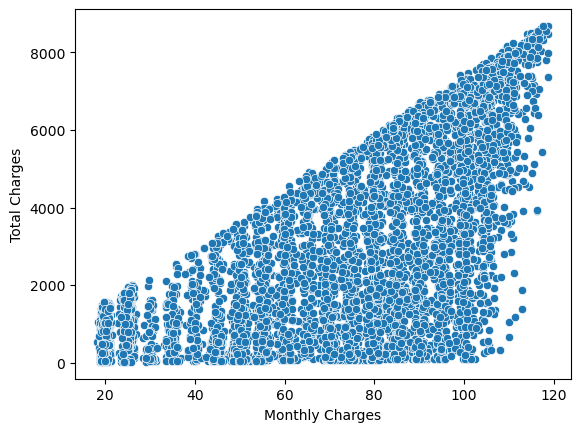

In [55]:
# check is there any relation between Monthly Charges and Total Charges
sns.scatterplot(x=df['Monthly Charges'],y=df['Total Charges'])
plt.show()  

In [56]:
df[['Monthly Charges', 'Total Charges']].corr()

,Monthly Charges,Total Charges
Monthly Charges,1.000000,0.651065
Total Charges,0.651065,1.000000


In [57]:
df=df.drop('Total Charges',axis=1)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7032 non-null   int64  
 1   Gender             7032 non-null   int64  
 2   Senior Citizen     7032 non-null   int64  
 3   Partner            7032 non-null   int64  
 4   Dependents         7032 non-null   int64  
 5   Tenure Months      7032 non-null   int64  
 6   Phone Service      7032 non-null   int64  
 7   Multiple Lines     7032 non-null   object 
 8   Internet Service   7032 non-null   object 
 9   Online Security    7032 non-null   object 
 10  Online Backup      7032 non-null   object 
 11  Device Protection  7032 non-null   object 
 12  Tech Support       7032 non-null   object 
 13  Streaming TV       7032 non-null   object 
 14  Streaming Movies   7032 non-null   object 
 15  Contract           7032 non-null   object 
 16  Paperless Billing  7032 non-n

In [59]:
df['Payment Method'].value_counts()

Payment Method
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

In [60]:
df['Payment Method']=df['Payment Method'].map({'Electronic check':0,'Mailed check':1,'Bank transfer (automatic)':2,'Credit card (automatic)':3})
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7032 non-null   int64  
 1   Gender             7032 non-null   int64  
 2   Senior Citizen     7032 non-null   int64  
 3   Partner            7032 non-null   int64  
 4   Dependents         7032 non-null   int64  
 5   Tenure Months      7032 non-null   int64  
 6   Phone Service      7032 non-null   int64  
 7   Multiple Lines     7032 non-null   object 
 8   Internet Service   7032 non-null   object 
 9   Online Security    7032 non-null   object 
 10  Online Backup      7032 non-null   object 
 11  Device Protection  7032 non-null   object 
 12  Tech Support       7032 non-null   object 
 13  Streaming TV       7032 non-null   object 
 14  Streaming Movies   7032 non-null   object 
 15  Contract           7032 non-null   object 
 16  Paperless Billing  7032 non-n

In [61]:
df['Multiple Lines'].value_counts()

Multiple Lines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

In [62]:
df['Multiple Lines']=df['Multiple Lines'].map({'No phone service':0,'No':1,'Yes':2})
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7032 non-null   int64  
 1   Gender             7032 non-null   int64  
 2   Senior Citizen     7032 non-null   int64  
 3   Partner            7032 non-null   int64  
 4   Dependents         7032 non-null   int64  
 5   Tenure Months      7032 non-null   int64  
 6   Phone Service      7032 non-null   int64  
 7   Multiple Lines     7032 non-null   int64  
 8   Internet Service   7032 non-null   object 
 9   Online Security    7032 non-null   object 
 10  Online Backup      7032 non-null   object 
 11  Device Protection  7032 non-null   object 
 12  Tech Support       7032 non-null   object 
 13  Streaming TV       7032 non-null   object 
 14  Streaming Movies   7032 non-null   object 
 15  Contract           7032 non-null   object 
 16  Paperless Billing  7032 non-n

In [63]:
df['Internet Service'].value_counts()

Internet Service
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

In [64]:
df['Internet Service']=df['Internet Service'].map({'No':0,'DSL':1,'Fiber optic':2})
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7032 non-null   int64  
 1   Gender             7032 non-null   int64  
 2   Senior Citizen     7032 non-null   int64  
 3   Partner            7032 non-null   int64  
 4   Dependents         7032 non-null   int64  
 5   Tenure Months      7032 non-null   int64  
 6   Phone Service      7032 non-null   int64  
 7   Multiple Lines     7032 non-null   int64  
 8   Internet Service   7032 non-null   int64  
 9   Online Security    7032 non-null   object 
 10  Online Backup      7032 non-null   object 
 11  Device Protection  7032 non-null   object 
 12  Tech Support       7032 non-null   object 
 13  Streaming TV       7032 non-null   object 
 14  Streaming Movies   7032 non-null   object 
 15  Contract           7032 non-null   object 
 16  Paperless Billing  7032 non-n

In [65]:
df['Online Backup'].value_counts()

Online Backup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64

In [66]:
df['Online Backup']=df['Online Backup'].map({'No internet service':0,'No':1,'Yes':2})
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7032 non-null   int64  
 1   Gender             7032 non-null   int64  
 2   Senior Citizen     7032 non-null   int64  
 3   Partner            7032 non-null   int64  
 4   Dependents         7032 non-null   int64  
 5   Tenure Months      7032 non-null   int64  
 6   Phone Service      7032 non-null   int64  
 7   Multiple Lines     7032 non-null   int64  
 8   Internet Service   7032 non-null   int64  
 9   Online Security    7032 non-null   object 
 10  Online Backup      7032 non-null   int64  
 11  Device Protection  7032 non-null   object 
 12  Tech Support       7032 non-null   object 
 13  Streaming TV       7032 non-null   object 
 14  Streaming Movies   7032 non-null   object 
 15  Contract           7032 non-null   object 
 16  Paperless Billing  7032 non-n

In [67]:
df['Online Security'].value_counts()

Online Security
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

In [68]:
df['Online Security']=df['Online Security'].map({'No internet service':0,'No':1,'Yes':2})
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7032 non-null   int64  
 1   Gender             7032 non-null   int64  
 2   Senior Citizen     7032 non-null   int64  
 3   Partner            7032 non-null   int64  
 4   Dependents         7032 non-null   int64  
 5   Tenure Months      7032 non-null   int64  
 6   Phone Service      7032 non-null   int64  
 7   Multiple Lines     7032 non-null   int64  
 8   Internet Service   7032 non-null   int64  
 9   Online Security    7032 non-null   int64  
 10  Online Backup      7032 non-null   int64  
 11  Device Protection  7032 non-null   object 
 12  Tech Support       7032 non-null   object 
 13  Streaming TV       7032 non-null   object 
 14  Streaming Movies   7032 non-null   object 
 15  Contract           7032 non-null   object 
 16  Paperless Billing  7032 non-n

In [69]:
df['Device Protection'].value_counts()

Device Protection
No                     3094
Yes                    2418
No internet service    1520
Name: count, dtype: int64

In [70]:
df['Device Protection']=df['Device Protection'].map({'No internet service':0,'No':1,'Yes':2})
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7032 non-null   int64  
 1   Gender             7032 non-null   int64  
 2   Senior Citizen     7032 non-null   int64  
 3   Partner            7032 non-null   int64  
 4   Dependents         7032 non-null   int64  
 5   Tenure Months      7032 non-null   int64  
 6   Phone Service      7032 non-null   int64  
 7   Multiple Lines     7032 non-null   int64  
 8   Internet Service   7032 non-null   int64  
 9   Online Security    7032 non-null   int64  
 10  Online Backup      7032 non-null   int64  
 11  Device Protection  7032 non-null   int64  
 12  Tech Support       7032 non-null   object 
 13  Streaming TV       7032 non-null   object 
 14  Streaming Movies   7032 non-null   object 
 15  Contract           7032 non-null   object 
 16  Paperless Billing  7032 non-n

In [71]:
df['Tech Support'].value_counts()

Tech Support
No                     3472
Yes                    2040
No internet service    1520
Name: count, dtype: int64

In [72]:
df['Tech Support']=df['Tech Support'].map({'No internet service':0,'No':1,'Yes':2})

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7032 non-null   int64  
 1   Gender             7032 non-null   int64  
 2   Senior Citizen     7032 non-null   int64  
 3   Partner            7032 non-null   int64  
 4   Dependents         7032 non-null   int64  
 5   Tenure Months      7032 non-null   int64  
 6   Phone Service      7032 non-null   int64  
 7   Multiple Lines     7032 non-null   int64  
 8   Internet Service   7032 non-null   int64  
 9   Online Security    7032 non-null   int64  
 10  Online Backup      7032 non-null   int64  
 11  Device Protection  7032 non-null   int64  
 12  Tech Support       7032 non-null   int64  
 13  Streaming TV       7032 non-null   object 
 14  Streaming Movies   7032 non-null   object 
 15  Contract           7032 non-null   object 
 16  Paperless Billing  7032 non-n

In [74]:
df['Streaming TV'].value_counts()

Streaming TV
No                     2809
Yes                    2703
No internet service    1520
Name: count, dtype: int64

In [75]:
df['Streaming TV']=df['Streaming TV'].map({'No internet service':0,'No':1,'Yes':2})
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7032 non-null   int64  
 1   Gender             7032 non-null   int64  
 2   Senior Citizen     7032 non-null   int64  
 3   Partner            7032 non-null   int64  
 4   Dependents         7032 non-null   int64  
 5   Tenure Months      7032 non-null   int64  
 6   Phone Service      7032 non-null   int64  
 7   Multiple Lines     7032 non-null   int64  
 8   Internet Service   7032 non-null   int64  
 9   Online Security    7032 non-null   int64  
 10  Online Backup      7032 non-null   int64  
 11  Device Protection  7032 non-null   int64  
 12  Tech Support       7032 non-null   int64  
 13  Streaming TV       7032 non-null   int64  
 14  Streaming Movies   7032 non-null   object 
 15  Contract           7032 non-null   object 
 16  Paperless Billing  7032 non-n

In [76]:
df['Streaming Movies']=df['Streaming Movies'].map({'No internet service':0,'No':1,'Yes':2})
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7032 non-null   int64  
 1   Gender             7032 non-null   int64  
 2   Senior Citizen     7032 non-null   int64  
 3   Partner            7032 non-null   int64  
 4   Dependents         7032 non-null   int64  
 5   Tenure Months      7032 non-null   int64  
 6   Phone Service      7032 non-null   int64  
 7   Multiple Lines     7032 non-null   int64  
 8   Internet Service   7032 non-null   int64  
 9   Online Security    7032 non-null   int64  
 10  Online Backup      7032 non-null   int64  
 11  Device Protection  7032 non-null   int64  
 12  Tech Support       7032 non-null   int64  
 13  Streaming TV       7032 non-null   int64  
 14  Streaming Movies   7032 non-null   int64  
 15  Contract           7032 non-null   object 
 16  Paperless Billing  7032 non-n

In [77]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [78]:
df['Contract']=df['Contract'].map({'Month-to-month':0,'One year':1,'Two year':2})
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7032 non-null   int64  
 1   Gender             7032 non-null   int64  
 2   Senior Citizen     7032 non-null   int64  
 3   Partner            7032 non-null   int64  
 4   Dependents         7032 non-null   int64  
 5   Tenure Months      7032 non-null   int64  
 6   Phone Service      7032 non-null   int64  
 7   Multiple Lines     7032 non-null   int64  
 8   Internet Service   7032 non-null   int64  
 9   Online Security    7032 non-null   int64  
 10  Online Backup      7032 non-null   int64  
 11  Device Protection  7032 non-null   int64  
 12  Tech Support       7032 non-null   int64  
 13  Streaming TV       7032 non-null   int64  
 14  Streaming Movies   7032 non-null   int64  
 15  Contract           7032 non-null   int64  
 16  Paperless Billing  7032 non-n

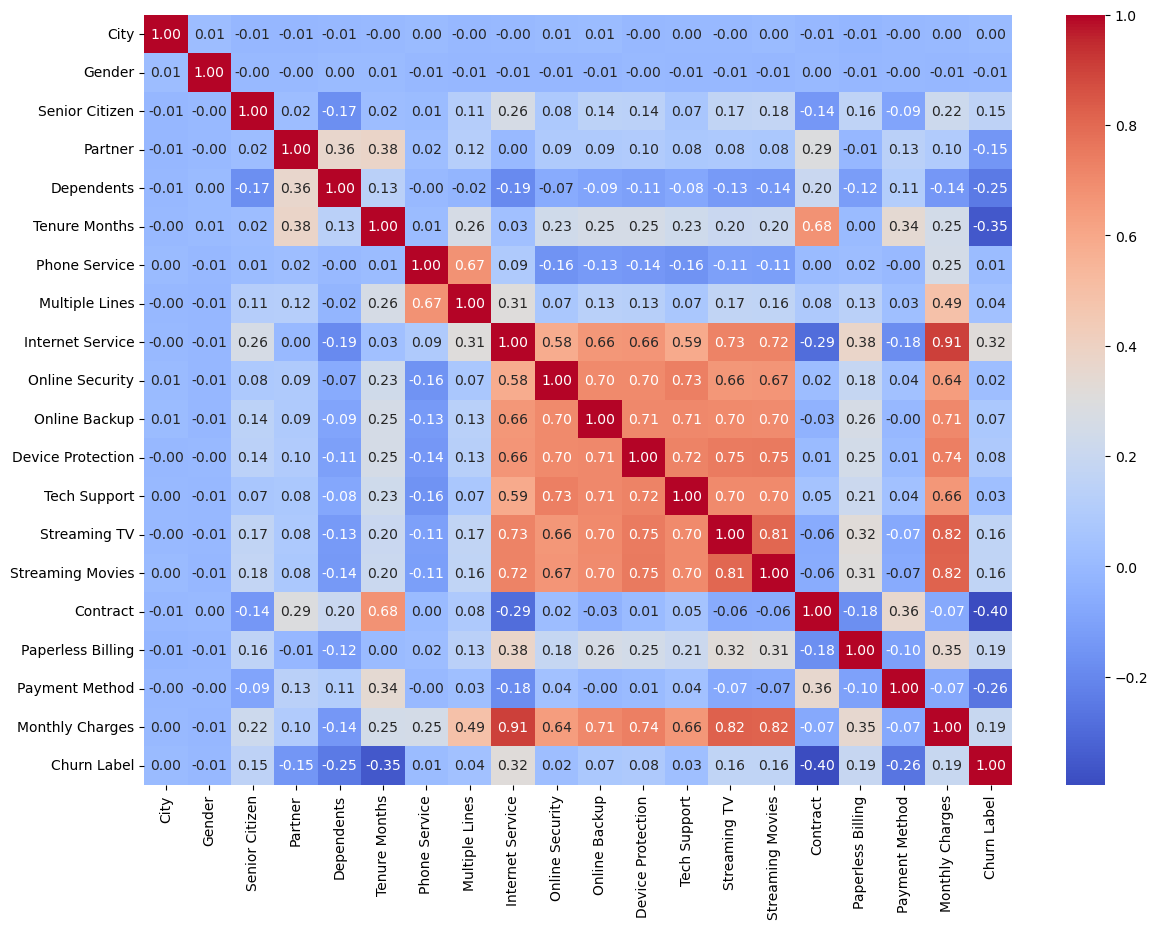

In [79]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [80]:
features = [
    'Senior Citizen',
    'Partner',
    'Dependents',
    'Tenure Months',
    'Multiple Lines',
    'Internet Service',
    'Online Security',
    'Online Backup',
    'Device Protection',
    'Tech Support',
    'Streaming TV',
    'Contract',
    'Paperless Billing',
    'Payment Method',
    'Monthly Charges'
]

In [81]:
# only select the columns which are in features list and Churn Label column
data = df[features + ['Churn Label']]

In [82]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Senior Citizen     7032 non-null   int64  
 1   Partner            7032 non-null   int64  
 2   Dependents         7032 non-null   int64  
 3   Tenure Months      7032 non-null   int64  
 4   Multiple Lines     7032 non-null   int64  
 5   Internet Service   7032 non-null   int64  
 6   Online Security    7032 non-null   int64  
 7   Online Backup      7032 non-null   int64  
 8   Device Protection  7032 non-null   int64  
 9   Tech Support       7032 non-null   int64  
 10  Streaming TV       7032 non-null   int64  
 11  Contract           7032 non-null   int64  
 12  Paperless Billing  7032 non-null   int64  
 13  Payment Method     7032 non-null   int64  
 14  Monthly Charges    7032 non-null   float64
 15  Churn Label        7032 non-null   int64  
dtypes: float64(1), int64(15)
memo

In [83]:
#split into x and y
X = data.drop('Churn Label',axis=1)
y = data['Churn Label']

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [85]:
# model 1 random forest classifier
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [86]:
#model 2 logistic regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

c:\Users\keert\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

In [87]:
# check the accuracy of both the models
from sklearn.metrics import accuracy_score
y_pred_rfc = rfc.predict(X_test)
y_train_pred_rfc = rfc.predict(X_train)
y_pred_lr = lr.predict(X_test)
y_train_pred_lr = lr.predict(X_train)

print("Random Forest Classifier train Accuracy:", accuracy_score(y_train, y_train_pred_rfc))
print("Random Forest Classifier test Accuracy:", accuracy_score(y_test, y_pred_rfc))
print("Logistic Regression train Accuracy:", accuracy_score(y_train, y_train_pred_lr))
print("Logistic Regression test Accuracy:", accuracy_score(y_test, y_pred_lr))

Random Forest Classifier train Accuracy: 0.9966222222222222
Random Forest Classifier test Accuracy: 0.7846481876332623
Logistic Regression train Accuracy: 0.8067555555555556
Logistic Regression test Accuracy: 0.8109452736318408


<Axes: >

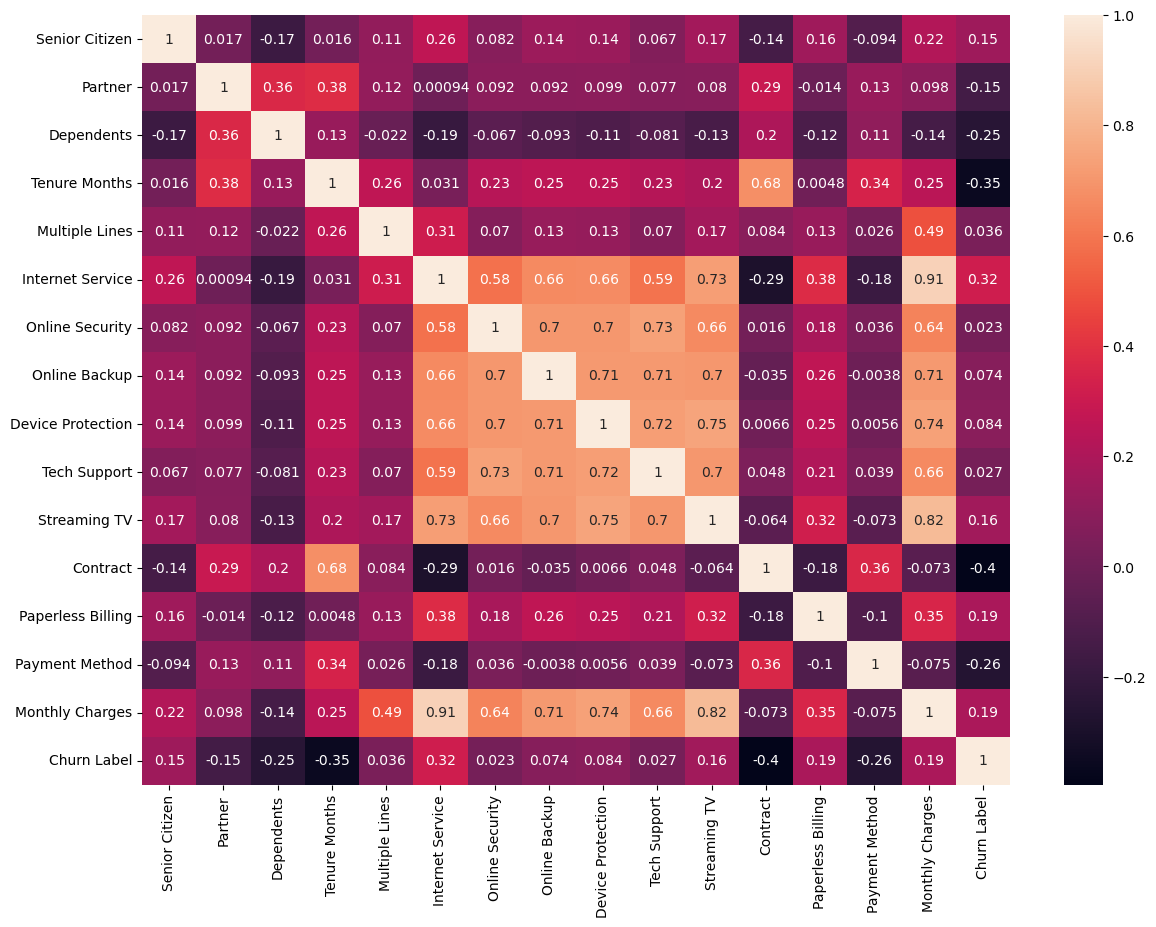

In [90]:
plt.figure(figsize=(14,10))
sns.heatmap(data.corr(),annot=True)

In [ ]:
features = [
    'Senior Citizen',
    'Partner',
    'Dependents',
    'Tenure Months',
    'Streaming TV',
    'Contract',
    'Paperless Billing',
    'Payment Method',
    'Monthly Charges'
]

In [91]:
x=df[features]
y=df['Churn Label']

In [92]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [94]:
#logistic regression
lr = LogisticRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)
y_train_pred_lr = lr.predict(x_train)
print("Logistic Regression train Accuracy:", accuracy_score(y_train, y_train_pred_lr))
print("Logistic Regression test Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression train Accuracy: 0.8067555555555556
Logistic Regression test Accuracy: 0.8109452736318408


c:\Users\keert\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [98]:
# random forest classifier
rfc = RandomForestClassifier(n_estimators=200, random_state=42)
rfc.fit(x_train, y_train)
y_pred_rfc = rfc.predict(x_test)
y_train_pred_rfc = rfc.predict(x_train)
print("Random Forest Classifier train Accuracy:", accuracy_score(y_train, y_train_pred_rfc))
print("Random Forest Classifier test Accuracy:", accuracy_score(y_test, y_pred_rfc))

Random Forest Classifier train Accuracy: 0.9966222222222222
Random Forest Classifier test Accuracy: 0.7910447761194029


In [102]:
!python -m pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [103]:
# xgboost classifier
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=200, random_state=42)
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)
y_train_pred_xgb = xgb.predict(x_train)
print("XGBoost Classifier train Accuracy:", accuracy_score(y_train, y_train_pred_xgb))
print("XGBoost Classifier test Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Classifier train Accuracy: 0.9706666666666667
XGBoost Classifier test Accuracy: 0.7768301350390903


In [105]:
# svm
from sklearn.svm import SVC
svm = SVC(random_state=42)
svm.fit(x_train, y_train)
y_pred_svm = svm.predict(x_test)
y_train_pred_svm = svm.predict(x_train)
print("SVM train Accuracy:", accuracy_score(y_train, y_train_pred_svm))
print("SVM test Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM train Accuracy: 0.7888
SVM test Accuracy: 0.7960199004975125


In [106]:
# knn
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)
y_train_pred_knn = knn.predict(x_train)
print("KNN train Accuracy:", accuracy_score(y_train, y_train_pred_knn))
print("KNN test Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN train Accuracy: 0.8405333333333334
KNN test Accuracy: 0.7711442786069652


In [107]:
# navi bayes
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_train, y_train)
y_pred_nb = nb.predict(x_test)
y_train_pred_nb = nb.predict(x_train)
print("Naive Bayes train Accuracy:", accuracy_score(y_train, y_train_pred_nb))
print("Naive Bayes test Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes train Accuracy: 0.7468444444444444
Naive Bayes test Accuracy: 0.746268656716418


In [108]:
# neural network
from sklearn.neural_network import MLPClassifier
nn = MLPClassifier(random_state=42)
nn.fit(x_train, y_train)
y_pred_nn = nn.predict(x_test)
y_train_pred_nn = nn.predict(x_train)
print("Neural Network train Accuracy:", accuracy_score(y_train, y_train_pred_nn))
print("Neural Network test Accuracy:", accuracy_score(y_test, y_pred_nn))

Neural Network train Accuracy: 0.8108444444444445
Neural Network test Accuracy: 0.8123667377398721
